# Transport Data

In [26]:
# Import Libraries

import pandas as pd  # data loading
import numpy as np   # performing numeric operation's 
import seaborn as sns  # High visualization 
import matplotlib.pyplot as plt  # Graphs , plots foundation 

# Load file using correct path
df = pd.read_csv(r"C:\Users\sarang\OneDrive\Desktop\transport data.csv")


In [27]:
df.head()

,Trip_ID,Trip_Date,Vehicle_Type,Distance_km,Fare,City
0,1,01-01-2023,Taxi,NaN,0.0,CityB
1,2,01-01-2023,NaN,NaN,0.0,CityA
2,3,NaN,NaN,20.0,NaN,CityC
3,4,01-01-2023,NaN,NaN,-50.0,CityC
4,5,01-01-2023,Auto,20.0,200.0,CityA


In [28]:
# Rows and Column check

import pandas as pd

df = pd.read_csv(r"C:\Users\sarang\OneDrive\Desktop\transport data.csv")
print(df.shape)
print(df.columns)


(550, 6)
Index(['Trip_ID', 'Trip_Date', 'Vehicle_Type', 'Distance_km', 'Fare', 'City'], dtype='object')


In [29]:
# Basic info
df.info()

# Check missing values

df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Trip_ID       550 non-null    int64  
 1   Trip_Date     418 non-null    object 
 2   Vehicle_Type  434 non-null    object 
 3   Distance_km   330 non-null    float64
 4   Fare          451 non-null    float64
 5   City          550 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 25.9+ KB


Trip_ID           0
Trip_Date       132
Vehicle_Type    116
Distance_km     220
Fare             99
City              0
dtype: int64

In [30]:
# Mising Values Handle

df['Trip_Date'] = df['Trip_Date'].fillna(df['Trip_Date'].mode()[0])
df['Vehicle_Type'] = df['Vehicle_Type'].fillna(df['Vehicle_Type'].mode()[0])
df['Distance_km'] = df['Distance_km'].fillna(df['Distance_km'].mean())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())




In [31]:
# Missing Values Verify

df.isnull().sum()


Trip_ID         0
Trip_Date       0
Vehicle_Type    0
Distance_km     0
Fare            0
City            0
dtype: int64

In [32]:
# Remove Duplicate Values

df.duplicated().sum()  # kitne duplicate rows
df.drop_duplicates(inplace=True)
df.shape

(550, 6)

In [33]:
df["Trip_Date"] = pd.to_datetime(df["Trip_Date"], errors="coerce")

# Check result
df[["Trip_Date"]].head()


,Trip_Date
0,2023-01-01
1,2023-01-01
2,2023-01-01
3,2023-01-01
4,2023-01-01


In [34]:
df["Vehicle_Type"] = df["Vehicle_Type"].str.lower().str.strip()
df["Vehicle_Type"].value_counts()


Vehicle_Type
taxi    229
bus     215
auto    106
Name: count, dtype: int64

In [35]:
# Convert to numeric, coerce invalid
df["Distance_km"] = pd.to_numeric(df["Distance_km"], errors="coerce")
df["Fare"] = pd.to_numeric(df["Fare"], errors="coerce")

# Check summary
df[["Distance_km", "Fare"]].describe()


,Distance_km,Fare
count,550.000000,550.000000
mean,20.212121,49.454545
std,6.226618,92.179009
min,10.000000,-50.000000
25%,20.000000,0.000000
50%,20.212121,0.000000
75%,20.212121,100.000000
max,30.000000,200.000000


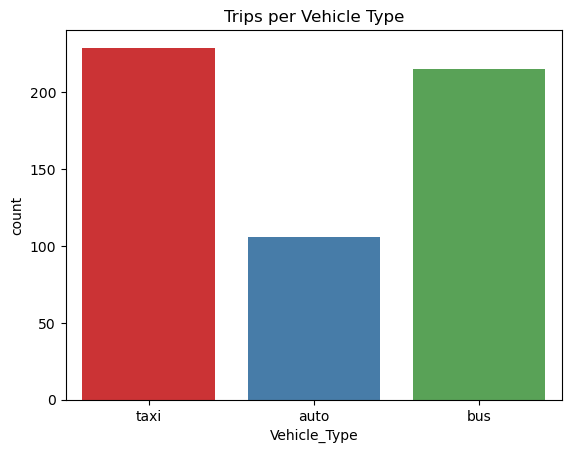

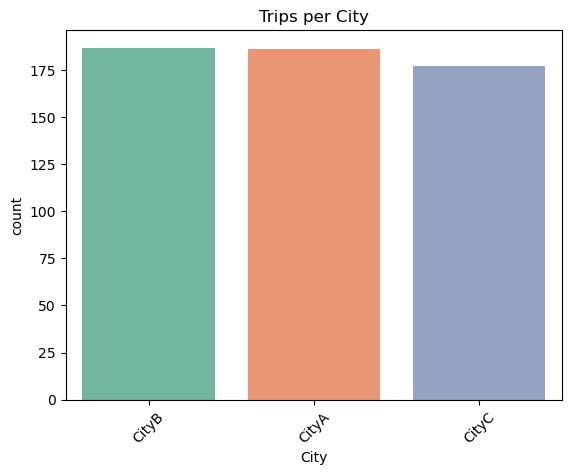

In [50]:
# Visualization

sns.countplot(x='Vehicle_Type', hue='Vehicle_Type', data=df,
              palette='Set1', legend=False)
plt.title('Trips per Vehicle Type')
plt.show()



sns.countplot(x='City', hue='City', data=df,
              palette='Set2', legend=False)
plt.title('Trips per City')
plt.xticks(rotation=45)
plt.show()


## Count plot
# Kaunsa vehicle sabse zyada use hua.
# Demand distribution kaisi hai.
# Kaunsi city me sabse zyada trips ho rahi hain.

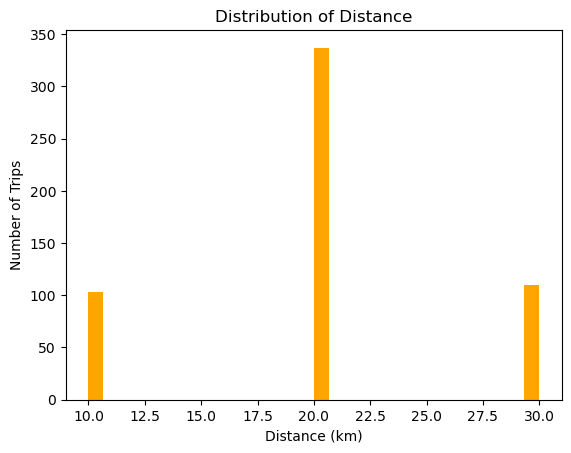

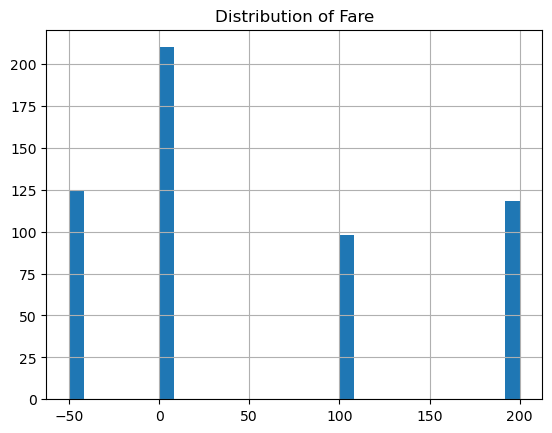

In [51]:
plt.hist(df['Distance_km'], bins=30, color='orange')
plt.title('Distribution of Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Number of Trips')
plt.show()


df['Fare'].hist(bins=30)
plt.title('Distribution of Fare')
plt.show()

## Histogram (Distance)
# Trips generally short hain ya long.
# Data left side me high hai to short trips zyada.

## (Fare)
# Log usually kitna pay karte hain.
# Typical fare range kya hai.

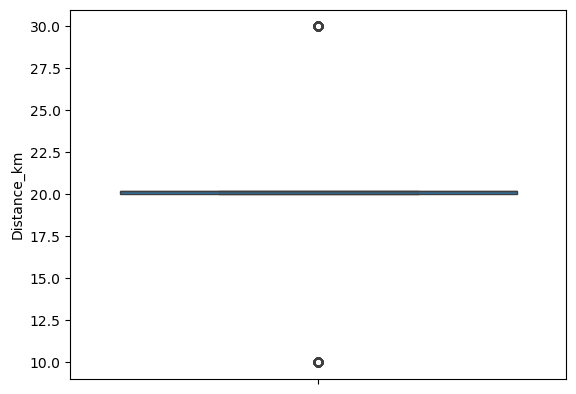

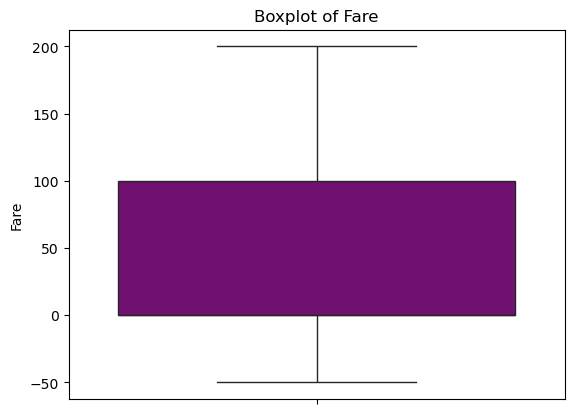

In [52]:
sns.boxplot(y='Distance_km', data=df)
plt.show()

sns.boxplot(y='Fare', data=df, color='purple')
plt.title('Boxplot of Fare')
plt.show()

## Boxplot
# ye batata hai data ka spread, typical value, aur extreme values ek hi graph me hai.
# Beech ki line = median (aadha data iske upar, aadha neeche)
# Box ka neeche wala part = 25th percentile
# Box ka upar wala part = 75th percentile
#      → matlab box ke andar 50% normal data aata hai

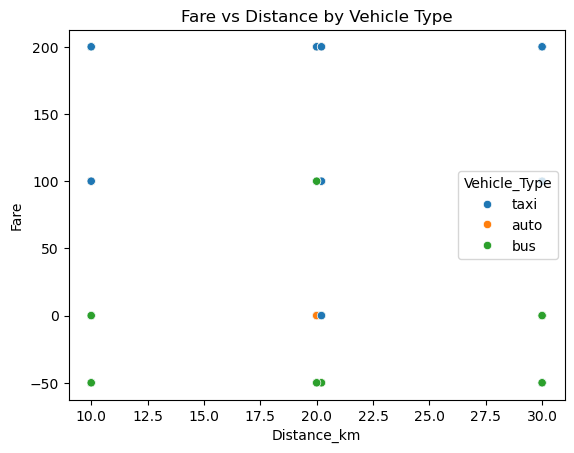

In [39]:
sns.scatterplot(x='Distance_km', y='Fare', hue='Vehicle_Type', data=df)
plt.title('Fare vs Distance by Vehicle Type')
plt.show()

## Scatter plot
# Distance badhne par fare ka behaviour kya hai yh btata hai.

# Conlusion 

In [ ]:
# This project analyzes raw transport data to understand travel patterns and pricing behavior.

This project examines cleaned transport data to uncover travel trends, pricing structure, and revenue distribution. 
The analysis reveals that transport usage is not evenly distributed; certain cities and vehicle categories generate significantly 
higher demand than others. 
Most trips fall within short to medium distances, while fares increase proportionally with distance, confirming a structured distance-based 
pricing model.

The study also highlights that specific vehicle types contribute more heavily to overall revenue due to higher usage frequency. 
Although the majority of trips follow consistent patterns, a small number of unusually long and high-cost journeys act as outliers and have a noticeable
impact on total earnings. Additionally, travel demand peaks during specific days and months, indicating seasonal or time-based variations.

Overall, the insights suggest that focusing on high-demand locations, peak periods, and frequently used vehicle categories can improve operational 
efficiency and profitability in the transport system.

Main purpose:
* To use cleaned transport data to identify demand patterns, understand fare behavior, and support better transport planning and decision-making.